In [1]:
PATH = "./experiments/interpolation"

### SDF Visualizations

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from typing import Tuple, Dict, List

from experiments.interpolation.config import cfg, ModelsConfig, TrainingConfig, InterpolationConfig
from experiments.interpolation.sdf import generate_points, SDFDataset
from experiments.interpolation.boundary import Boundary, CircleBoundary, StarBoundary

In [3]:
def get_signed_intensity(signed_distance: torch.Tensor):
    intensity = np.exp(-np.abs(signed_distance))
    signed_intensity = np.sign(signed_distance) * intensity
    return signed_intensity

def visualize_sdf_boundary(boundary: Boundary, bins: int, title: str = "", ax = None, use_intensity: bool = True):
    points = generate_points(bins=bins)
    signed_distance = boundary.get_signed_distance(points).detach().cpu().numpy()

    if ax is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6))
    else:
        fig = ax.figure

    image = ax.scatter(
        points[:, 0].detach().cpu().numpy(),
        points[:, 1].detach().cpu().numpy(),
        c=get_signed_intensity(signed_distance) if use_intensity else signed_distance,
        cmap="coolwarm"
    )
    label = "Signed Intensity (sign(d) * exp(-|d|)" if use_intensity else "Signed Distance"
    fig.colorbar(image, ax=ax, label=label)

    if title:
        ax.set_title(title)
    return fig, ax

In [4]:
def visualize_circle_and_star_sdf(circle_boundary: CircleBoundary, star_boundary: StarBoundary, bins: int):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

    # Circle
    visualize_sdf_boundary(circle_boundary, bins=bins, title="Circle SDF", ax=axes[0])

    # Star
    visualize_sdf_boundary(star_boundary, bins=bins, title="Star SDF", ax=axes[1])

    plt.show()

In [5]:
circle_boundary = CircleBoundary(radius=cfg.CircleCfg.radius)
star_boundary = StarBoundary(inner_radius=cfg.StarCfg.inner_radius, outer_radius=cfg.StarCfg.outer_radius)

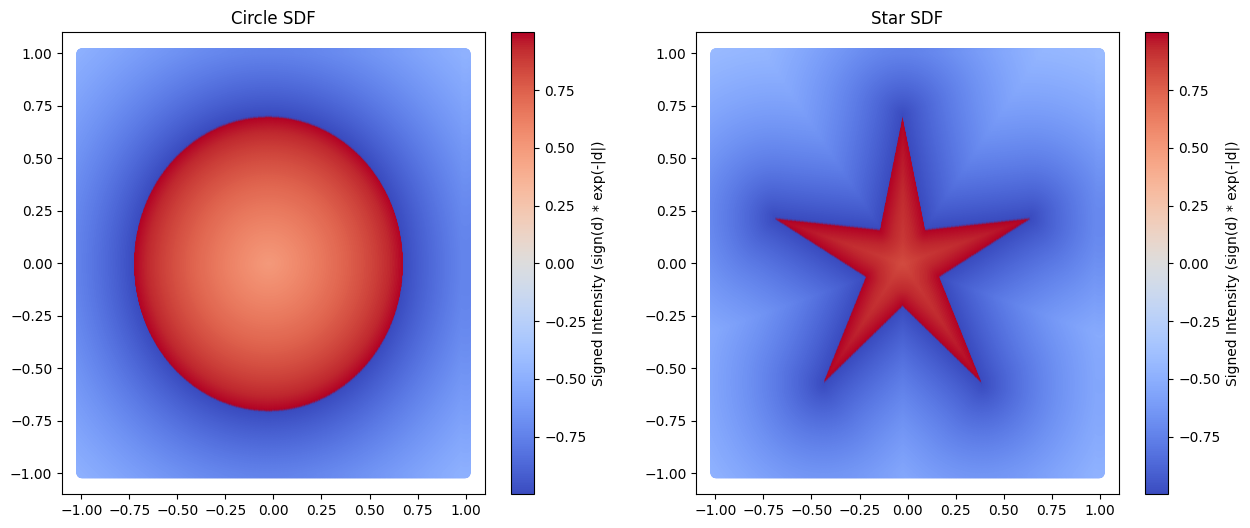

In [6]:
visualize_circle_and_star_sdf(circle_boundary, star_boundary, bins=cfg.InterCfg.bins)

### Dataset & DataLoaders

In [7]:
def generate_circle_and_star_training_dataset(
    circle_boundary: CircleBoundary,
    star_boundary: StarBoundary,
    num_points: int
) -> SDFDataset:

    grid_points = generate_points(num_points=num_points)

    circle_signed_distance = circle_boundary.get_signed_distance(grid_points).reshape(-1, 1)
    circle_interpolation_coef = 0.0 * torch.ones_like(circle_signed_distance)

    star_signed_distance = star_boundary.get_signed_distance(grid_points).reshape(-1, 1)
    star_interpolation_coef = 1.0 * torch.ones_like(star_signed_distance)
    
    points = torch.cat(
        [grid_points, grid_points], dim=0
    )
    signed_distance = torch.cat(
        [circle_signed_distance, star_signed_distance], dim=0
    )
    interpolation_coef = torch.cat(
        [circle_interpolation_coef, star_interpolation_coef], dim=0
    )
    return SDFDataset(
        points=points,
        interpolation_coef=interpolation_coef,
        signed_distance=signed_distance
    )

In [8]:
def split_dataset(dataset: SDFDataset, training_cfg: TrainingConfig):
    train_set, val_set, test_set = torch.utils.data.random_split(
        dataset, [training_cfg.train_share, training_cfg.val_share, training_cfg.test_share]
    )
    return train_set, val_set, test_set

def prepare_dataloaders(dataset: SDFDataset, training_cfg: TrainingConfig):
    train_set, val_set, test_set = split_dataset(dataset, training_cfg)
    train_loader = DataLoader(
        train_set,
        batch_size=training_cfg.batch_size,
        shuffle=True,
        num_workers=training_cfg.num_workers
    )
    val_loader = DataLoader(
        val_set,
        batch_size=training_cfg.batch_size,
        shuffle=False,
        num_workers=training_cfg.num_workers
    )
    test_loader = DataLoader(
        test_set,
        batch_size=training_cfg.batch_size,
        shuffle=False,
        num_workers=training_cfg.num_workers
    )
    return train_loader, val_loader, test_loader

In [9]:
dataset = generate_circle_and_star_training_dataset(circle_boundary, star_boundary, cfg.TrainingCfg.num_points_per_shape)

In [10]:
print(f"Dataset: {len(dataset)}.")

Dataset: 1000000.


In [11]:
train_loader, val_loader, test_loader = prepare_dataloaders(dataset, cfg.TrainingCfg)

/home/vagiz/Desktop/desktop_vagiz/HSE/Programming/sumo-rl/.venv/lib/python3.12/site-packages/torch/utils/data/dataset.py:469: UserWarning: Length of split at index 2 is 0. This might result in an empty dataset.
  warnings.warn(


In [12]:
print(f"Train batches: {len(train_loader)}.")
print(f"Val batches: {len(val_loader)}.")
print(f"Test batches: {len(test_loader)}.")

Train batches: 98.
Val batches: 25.
Test batches: 0.


In [13]:
points_example, signed_distance_example = next(iter(train_loader))
print(points_example.shape)
print(signed_distance_example.shape)

torch.Size([8192, 3])
torch.Size([8192, 1])


### Models

In [14]:
from src.sns.model import Model
from src.sns.mlp import MLP
from src.sns.linear import SimpleLinear, LipLinear, SmoothLinear
from src.sns.loss import LipLoss, SNSLoss

In [15]:
def create_models_for_experiment(model_cfg: ModelsConfig, training_cfg: TrainingConfig):
    vanilla_mlp = MLP(linear_cls=SimpleLinear, hidden_sizes=model_cfg.hidden_sizes, act=model_cfg.act)
    vanilla_model = Model(
        name="Standard MLP",
        mlp=vanilla_mlp,
        loss_fn=training_cfg.main_loss_fn
    )

    lip_mlp = MLP(
        linear_cls=LipLinear,
        hidden_sizes=model_cfg.hidden_sizes,
        act=model_cfg.act,
        initial_c=model_cfg.initial_c,
        normalization_eps=model_cfg.normalization_eps
    )
    lip_model = Model(
        name=f"Lipschitz MLP (lambda={model_cfg.lip_reg_coef})",
        mlp=lip_mlp,
        loss_fn=LipLoss(
            regularization_coef=model_cfg.lip_reg_coef,
            main_loss=training_cfg.main_loss_fn
        )
    )

    sns1_mlp = MLP(
        linear_cls=SmoothLinear,
        hidden_sizes=model_cfg.hidden_sizes,
        act=model_cfg.act,
        initial_c=model_cfg.initial_c,
        normalization_eps=model_cfg.normalization_eps
    )
    sns1_model = Model(
        name=f"First-order SNS (lambda={model_cfg.sns1_reg_coef})",
        mlp=sns1_mlp,
        loss_fn=SNSLoss(
            k=1,
            budget=model_cfg.sensitivity_budget,
            regularization_coef=model_cfg.sns1_reg_coef,
            main_loss=training_cfg.main_loss_fn
        )
    )

    sns2_mlp = MLP(
        linear_cls=SmoothLinear,
        hidden_sizes=model_cfg.hidden_sizes,
        act=model_cfg.act,
        initial_c=model_cfg.initial_c,
        normalization_eps=model_cfg.normalization_eps
    )
    sns2_model = Model(
        name=f"Second-order SNS (lambda={model_cfg.sns2_reg_coef})",
        mlp=sns2_mlp,
        loss_fn=SNSLoss(
            k=2,
            budget=model_cfg.curvature_budget_fn(model_cfg.sensitivity_budget, len(model_cfg.hidden_sizes) - 1),
            regularization_coef=model_cfg.sns2_reg_coef,
            main_loss=training_cfg.main_loss_fn
        )
    )
    return {
        vanilla_model.name: vanilla_model,
        lip_model.name: lip_model,
        sns1_model.name: sns1_model,
        sns2_model.name: sns2_model
    }

In [16]:
models = create_models_for_experiment(model_cfg=cfg.ModelsCfg, training_cfg=cfg.TrainingCfg)

In [17]:
models["Standard MLP"].mlp

MLP(
  (linear_layers): ModuleList(
    (0-5): 6 x SimpleLinear()
  )
  (act): Softplus(beta=1.0, threshold=20.0)
)

### Training Ground

In [18]:
import os
import torch.nn.functional as F
from tqdm.notebook import tqdm, trange

In [19]:
def run_epoch(is_train: bool, model: Model, opt: torch.optim.Optimizer | None, loader: DataLoader, metrics: Dict, device: str):
    if is_train:
        model.train()
    else:
        model.eval()

    epoch_loss = 0.0
    epoch_mse = 0.0
    epoch_circle_mse = 0.0
    epoch_star_mse = 0.0
    for (x, y) in loader:
        x, y = x.to(device), y.to(device)

        loss, y_hat = model.get_loss(x, y, return_prediction=True)

        if is_train:
            opt.zero_grad()
            loss.backward()
            opt.step()

        epoch_loss += loss.detach().cpu().item()
        epoch_mse  += F.mse_loss(y_hat, y).detach().cpu().item()

        is_circle = x[:, 2] == 0.0
        is_star = x[:, 2] == 1.0

        epoch_circle_mse += F.mse_loss(y_hat[is_circle], y[is_circle]).detach().cpu().item()
        epoch_star_mse += F.mse_loss(y_hat[is_star], y[is_star]).detach().cpu().item()

    metrics["total_loss"].append(epoch_loss / len(loader))
    metrics["mse"].append(epoch_mse / len(loader))

    bound, curvature = model.mlp.get_bound_and_curvature()
    metrics["bound"].append(bound.detach().cpu().item())
    metrics["curvature"].append(curvature.detach().cpu().item())

    metrics["circle_mse"].append(epoch_circle_mse / len(loader))
    metrics["star_mse"].append(epoch_star_mse / len(loader))


def train_model(model: Model, train_loader: DataLoader, val_loader: DataLoader, training_cfg: TrainingConfig):
    model.to(training_cfg.device)

    opt = torch.optim.Adam(model.parameters(), lr=training_cfg.lr, betas=training_cfg.betas)

    metrics = {
        "train": {"total_loss": [], "mse": [], "circle_mse": [], "star_mse": [], "bound": [], "curvature": []},
        "val"  : {"total_loss": [], "mse": [], "circle_mse": [], "star_mse": [], "bound": [], "curvature": []}
    }
    for epoch in trange(1, training_cfg.num_epochs + 1, desc=f"Train [{model.name}]"):
        run_epoch(
            is_train=True,
            model=model,
            opt=opt,
            loader=train_loader,
            metrics=metrics["train"],
            device=training_cfg.device
        )
        run_epoch(
            is_train=False,
            model=model,
            opt=None,
            loader=val_loader,
            metrics=metrics["val"],
            device=training_cfg.device
        )
    return metrics

In [20]:
def train_and_save_models(models: Dict[str, Model], train_loader: DataLoader, val_loader: DataLoader, training_cfg: TrainingConfig):
    metrics = {}

    for model_name in models:
        model_losses = train_model(models[model_name], train_loader, val_loader, training_cfg)
        metrics[model_name] = model_losses

    for model_name, model in models.items():
        file_name = f"/{'_'.join(model_name.split(' '))}.ckpt"
        save_dir = PATH + training_cfg.path_prefix + training_cfg.save_ckpt_dir

        os.makedirs(save_dir, exist_ok=True)
        torch.save(model.state_dict(), save_dir + file_name)

    return metrics

In [ ]:
metrics = train_and_save_models(models=models, train_loader=train_loader, val_loader=val_loader, training_cfg=cfg.TrainingCfg)

Train [Standard MLP]:   0%|          | 0/800 [00:00<?, ?it/s]

Train [Lipschitz MLP (lambda=0.001)]:   0%|          | 0/800 [00:00<?, ?it/s]

### Loss Curves

In [ ]:
import numpy as np

In [ ]:
def visualize_losses(metrics: Dict, title: str, save_dir: str = None):
    subset_names = ("train", "val")
    metric_names = list(list(list(metrics.values())[0].values())[0].keys())

    fig, axes = plt.subplots(
        nrows=len(metric_names),
        ncols=len(subset_names),
        figsize=(6 * len(subset_names), 5 * len(metric_names))
    )

    for metric_idx in range(len(metric_names)):
        metric_name = metric_names[metric_idx]
        for subset_idx in range(len(subset_names)):
            subset_name = subset_names[subset_idx]
            axes[metric_idx][subset_idx].set(
                title=subset_name.title(),
                xlabel="Epoch",
                ylabel=metric_name.replace("_", " ").title() + " (Log10 Scale)"
            )

            for model_name, model_metrics in metrics.items():
                loss_values = model_metrics[subset_name][metric_name]
                axes[metric_idx][subset_idx].plot(
                    np.arange(1, len(loss_values) + 1),
                    np.log10(loss_values),
                    label=model_name
                )

            axes[metric_idx][subset_idx].legend()

    fig.suptitle(title)
    fig.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(f"{save_dir}/metrics.png")
    plt.show()

In [ ]:
visualize_losses(metrics, title="Metrics for Interpolation Task", save_dir=PATH + cfg.TrainingCfg.path_prefix + cfg.TrainingCfg.save_plots_dir)

### Interpolation Task

In [ ]:
def generate_interpolation_datasets(ts: Tuple[float], bins: int) -> List[Tuple[float, SDFDataset]]:
    grid_points = generate_points(bins=bins)

    t_datasets = []
    for t in ts:
        interpolation_coef = t * torch.ones((grid_points.size(0), 1), device=grid_points.device)
        signed_distance = torch.zeros_like(interpolation_coef)  # placeholder

        dataset = SDFDataset(
            points=grid_points,
            interpolation_coef=interpolation_coef,
            signed_distance=signed_distance
        )
        t_datasets.append((t, dataset))
    return t_datasets

In [ ]:
def prepare_interpolation_dataloaders(t_datasets: List[Tuple[float, SDFDataset]], training_cfg: TrainingConfig):
    t_dataloaders = []
    for (t, dataset) in t_datasets:
        dataloader = DataLoader(
            dataset,
            batch_size=training_cfg.batch_size,
            shuffle=False,
            num_workers=training_cfg.num_workers
        )
        t_dataloaders.append((t, dataloader))
    return t_dataloaders

In [ ]:
def inference_models(models: Dict[str, Model], t_dataloaders: List[Tuple[float, DataLoader]]):
    outputs = {}

    for model_name in tqdm(models, desc="Inference on interpolation datasets"):
        outputs[model_name] = []

        model = models[model_name]
        model.eval()
        model.cpu()
        for (t, dataloader) in tqdm(t_dataloaders, desc=f"Inference [{model_name}]"):
            points, output = [], []
            for (x, _) in dataloader:
                points.append(x[:, :2].detach().cpu())
                output.append(model(x).detach().cpu())
        
            outputs[model_name].append((
                t,
                torch.cat(points, dim=0).numpy(),
                torch.cat(output, dim=0).numpy()
            ))
    return outputs

In [ ]:
def visualize_interpolation(outputs, use_intensity: bool = True, save_dir: str = None):
    model_names = list(outputs.keys())

    output = outputs[model_names[0]]
    ts = [output[i][0] for i in range(len(output))]

    fig, axes = plt.subplots(nrows=len(model_names), ncols=len(ts), figsize=(25, 20), sharey=True)

    for model_idx, model_name in enumerate(model_names):
        axes[model_idx][0].set(ylabel=model_name)
        for t_idx, t in enumerate(ts):
            ax = axes[model_idx][t_idx]

            assert t == outputs[model_name][t_idx][0], f"t={t} from ts != t={outputs[model_name][t_idx][0]} from dict"
            points = outputs[model_name][t_idx][1]
            output = outputs[model_name][t_idx][2]

            ax.scatter(
                points[:, 0],
                points[:, 1],
                c=get_signed_intensity(output) if use_intensity else output,
                cmap="coolwarm"
            )
            # fig.colorbar(image, ax=ax, label="Signed Distance")
            ax.set(title=f"t = {t}")
    
    fig.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(f"{save_dir}/interpolation.png")
    plt.show()

In [ ]:
t_datasets = generate_interpolation_datasets(ts=cfg.InterCfg.ts, bins=cfg.InterCfg.bins)
t_dataloaders = prepare_interpolation_dataloaders(t_datasets=t_datasets, training_cfg=cfg.TrainingCfg)

In [ ]:
outputs = inference_models(models=models, t_dataloaders=t_dataloaders)

In [ ]:
visualize_interpolation(
    outputs,
    use_intensity=True,
    save_dir=PATH + cfg.TrainingCfg.path_prefix + cfg.TrainingCfg.save_plots_dir
)